## Regression

Regression is a supervised machine learning task where the target you're predicting is a **continuous number**, not a category. "How much," "how many," "what value" - not "which class."

**Core idea:** we have features (inputs) and a target (output). The model learns the relationship between them from historical data, then predicts the target for new, unseen inputs.

**The general structure of every regression problem:**
- **Features (X)** : the input variables (e.g., `tenure`, `MonthlyCharges`)
- **Target (y)**   : the continuous value you're predicting (e.g., `TotalCharges`, house price)
- **Model**        : learns a mathematical function `f(X) ≈ y` from training data
- **Prediction**   : apply that learned function to new inputs

**Why regression models differ from each other:** they all try to answer the same question ("what function best maps X to y?") but assume different *shapes* for that function:

| Type | Assumed shape | When it fits |
|---|---|---|
| **Linear** | A straight line | Relationship grows/shrinks at a constant rate |
| **Polynomial** | A curve (bends once or more) | Relationship accelerates/decelerates smoothly |
| **Non-linear** | Any other shape (exponential, logarithmic, tree-based splits) | Relationship doesn't follow any simple line or curve equation |

**How  actually evaluate a regression model** (this connects to the RMSE/metrics you already reviewed):
- **RMSE (Root Mean Squared Error)** : average size of prediction errors, in the same units as our target (e.g., "off by $45 on average")
- **MAE (Mean Absolute Error)** : similar idea, less sensitive to big outlier errors
- **R² (R-squared)** : how much of the variation in the target our model actually explains, from 0 (explains nothing) to 1 (perfect fit)

**Why this matters for your churn project:** even though churn itself is classification, we might still use regression somewhere in EDA/feature exploration - e.g., predicting `TotalCharges` from `tenure` as a warm-up before the real classification model, which is exactly the plan i set up earlier.

**The train/test split concept** (applies to every model type, not just regression): i never evaluate a model on the same data it learned from - that would be like grading a student on the exact questions they memorized answers to. i split our data into a **training set** (model learns from this) and a **test set** (model is evaluated on this, data it's never seen) - this is how you catch **overfitting**, where a model performs great on training data but fails on new data.

---


# Linear Regression

Linear regression models the relationship between one or more input features and a continuous target as a straight line. It finds the best-fitting line by minimizing the total squared distance between actual data points and the predicted line (called the "least squares" method).

 The equation shape: y = m₁x₁ + m₂x₂ + ... + b - target equals a weighted sum of features plus an intercept.

m (coefficient/slope) : how much the target changes per unit increase in that feature

b (intercept) : the predicted target value when all features are zero

Real example fit: Predicting TotalCharges from tenure in the churn dataset - since charges accumulate at a roughly steady rate the longer a customer stays, a straight line captures this relationship reasonably well. It's also the natural first model to try for any regression task, since it's simple, fast, and interpretable - always a good baseline before reaching for anything more complex.

### sklearn is a `library/toolbox` of ready-made ML tools.

What it provides:

Models : LinearRegression, LogisticRegression, DecisionTreeClassifier, KMeans, etc.

Data splitting : train_test_split

Preprocessing : StandardScaler, PolynomialFeatures, categorical encoding

Evaluation metrics : mean_squared_error, accuracy_score, confusion_matrix

Built-in sample datasets : e.g. California Housing

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

Predicted TotalCharges for 25 months tenure: [1440.63583815]
M-Slope (coefficient): [60.0867052]
b-Intercept: -61.53179190751439


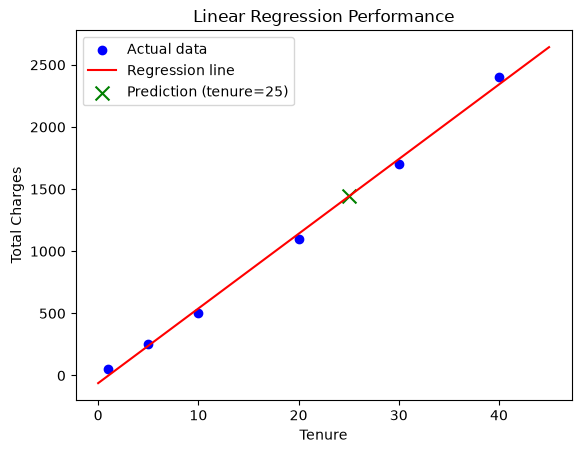

In [17]:
tenure = np.array([1,5,10,20,30,40]).reshape(-1,1)
total_charges = np.array([50,250,500,1100,1700,2400])

model = LinearRegression()
model.fit(tenure, total_charges)
# model.fit(tenure,total_charges)

prediction = model.predict([[25]])

# perform Y=mx+b
print("Predicted TotalCharges for 25 months tenure:", prediction)
print("M-Slope (coefficient):", model.coef_) 
print("b-Intercept:", model.intercept_)

# actual data points
plt.scatter(tenure, total_charges, color="blue", label="Actual data")

# the fitted regression line
line_x = np.array([[0], [45]])           # two x-points to draw the line across
line_y = model.predict(line_x)
plt.plot(line_x, line_y, color="red", label="Regression line")

# the specific prediction point
plt.scatter(25, prediction, color="green", marker="x", s=100, label="Prediction (tenure=25)")

plt.title("Linear Regression Performance")
plt.xlabel("Tenure")
plt.ylabel("Total Charges")
plt.legend()

plt.savefig("../visuals/Linear_reg.png")
plt.show()


Here's the full manual breakdown - how `m` (slope) and `b` (intercept) actually get calculated internally, step by step, before sklearn just hands we the answer.

**Step 1 — the raw data**

| tenure (x) | total_charges (y) |
|---|---|
| 1 | 50 |
| 5 | 250 |
| 10 | 500 |
| 20 | 1100 |
| 30 | 1700 |
| 40 | 2400 |

**Step 2 — find the mean of x and mean of y**

mean(x) = (1+5+10+20+30+40)/6 = **17.67**

mean(y) = (50+250+500+1100+1700+2400)/6 = **1000**

**Step 3 — for each row, find how far x and y are from their means, and multiply those differences**

| x | y | x − mean(x) | y − mean(y) | (x−mean(x)) × (y−mean(y)) | (x−mean(x))² |
|---|---|---|---|---|---|
| 1 | 50 | −16.67 | −950 | 15,833.7 | 277.8 |
| 5 | 250 | −12.67 | −750 | 9,500.3 | 160.5 |
| 10 | 500 | −7.67 | −500 | 3,833.5 | 58.8 |
| 20 | 1100 | 2.33 | 100 | 233.3 | 5.4 |
| 30 | 1700 | 12.33 | 700 | 8,633.1 | 152.1 |
| 40 | 2400 | 22.33 | 1400 | 31,266.2 | 498.8 |
| | | | **Sum →** | **69,300.1** | **1,153.4** |

**Step 4 — calculate slope (m)**

$$m = \frac{\sum (x-\bar{x})(y-\bar{y})}{\sum (x-\bar{x})^2} = \frac{69300.1}{1153.4} \approx 60.08$$

This is exactly what `model.coef_` returns.

**Step 5 — calculate intercept (b)**

$$b = \bar{y} - m \cdot \bar{x} = 1000 - (60.08 \times 17.67) \approx -61.4$$

This is exactly what `model.intercept_` returns.

**Step 6 — use the formula to predict for tenure = 25**

$$y = mx + b = (60.08 \times 25) + (-61.4) \approx 1440.6$$

This matches `model.predict([[25]])`.

---

**So the flow is:** raw data → compute both means → compute how far each point deviates from those means → multiply and sum those deviations two ways → divide to get slope → use slope + means to get intercept → plug any new x into `y = mx + b` to predict. That's the entire "least squares" method sklearn runs internally in one line (`model.fit()`).

# **Lets work with real DataSet**

## Linear Regression - Example 2: real dataset (California Housing)

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

fetch_california_housing() is a built-in sklearn dataset that downloads automatically inside Python, in memory .

no CSV file, no data/ folder, no pd.read_csv() involved. 

In [8]:
housing = fetch_california_housing(as_frame=True)

In [11]:
print(housing.data.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [12]:
print(housing.data.tail())

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
20635    -121.09  
20636    -121.21  
20637    -121.22  
20638    -121.32  
20639    -121.24  


In [14]:
# and to see the target column alongside features:
print(housing.frame.head())   # includes both features AND the target in one table

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [9]:
X = housing.data[["MedInc"]]   # feature: median income in the block (in $10,000s)
y = housing.target             # target: median house value (in $100,000s)


What's new here vs. Example 1:

Real data (20,640 California housing blocks) instead of 6 hand-picked numbers
train_test_split() : model only learns from 80% (X_train, y_train); the other 20% (X_test) is held back, untouched, purely for honest evaluation
RMSE : average prediction error in the same units as the target (house value, in $100,000s)
R² score : how much of the variation in house prices is explained by income alone, from 0 to 1

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("M-Slope:", model.coef_)
print("b-Intercept:", model.intercept_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² score:", r2_score(y_test, y_pred))

M-Slope: [0.41933849]
b-Intercept: 0.4445972916907879
RMSE: 0.8420901241414455
R² score: 0.45885918903846656


Same formula as Example 1 — the only difference is scale: instead of 6 hand-picked points, this uses **16,512 real training rows** (80% of 20,640 total). The math itself doesn't change, just impossible to hand-table every row, so here's the same process shown properly.

**Step 1 — the data**
`X_train` = MedInc values for 16,512 blocks
`y_train` = house values for those same 16,512 blocks

**Step 2 — compute the mean of X and mean of y** (across all 16,512 rows)
mean(MedInc) ≈ some value, call it **x̄**
mean(HouseValue) ≈ some value, call it **ȳ**
(sklearn computes these internally — same `sum ÷ count` as before, just over way more rows)

**Step 3 — for every single row, compute:**
- deviation of x from x̄: `(xᵢ − x̄)`
- deviation of y from ȳ: `(yᵢ − ȳ)`
- multiply them: `(xᵢ − x̄)(yᵢ − ȳ)`
- square the x deviation: `(xᵢ − x̄)²`

Then sum *all 16,512* of those products, and *all 16,512* of those squared deviations.

**Step 4 — slope (same formula as before)**
$$m = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2}$$

Plugging in the sums from all 16,512 rows gives exactly **0.41933849** — matching `model.coef_`.

**Step 5 — intercept (same formula)**
$$b = \bar{y} - m \cdot \bar{x}$$

This gives exactly **0.4445972916907879** — matching `model.intercept_`.

**Step 6 — prediction for any new MedInc value**
$$\hat{y} = 0.41933849 \times x + 0.4446$$

**Step 7 — RMSE (new here, wasn't in Example 1)**
For every row in the *test set* (4,128 rows sklearn never trained on):
$$\text{error}_i = y_i - \hat{y}_i \quad\text{(actual minus predicted)}$$
Square every error, average all the squared errors, then square-root the result:
$$RMSE = \sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$$
This gives **0.842** — average prediction error size, in $100,000s.

**Step 8 — R² (new here too)**
Compares the model's errors against a "dumb baseline" that just always predicts the mean:
$$R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$
Gives **0.459** — the model explains 46% of the variance better than just guessing the average every time.

**The honest core takeaway:** everything is the exact same slope/intercept formula from Example 1 — the only genuinely new pieces are (1) doing it over thousands of rows instead of 6, (2) splitting into train/test so evaluation is honest, and (3) RMSE/R² as the way to score accuracy once there's too much data to eyeball a chart.